In [1]:
# Step 1: Set up Kaggle API for dataset download
!git clone https://github.com/niaz1971/BRAIN_TUMOR_DETECTION_USING_DEEP_LEARNING.git

Cloning into 'BRAIN_TUMOR_DETECTION_USING_DEEP_LEARNING'...
remote: Enumerating objects: 354, done.
remote: Counting objects: 100% (354/354), done.
remote: Compressing objects: 100% (348/348), done.
remote: Total 354 (delta 37), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (354/354), 37.99 MiB | 9.94 MiB/s, done.
Resolving deltas: 100% (37/37), done.


In [2]:
cd BRAIN_TUMOR_DETECTION_USING_DEEP_LEARNING

/content/BRAIN_TUMOR_DETECTION_USING_DEEP_LEARNING


In [3]:
!pip install lime kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!unzip -q brain-tumor-mri-dataset.zip
!rm brain-tumor-mri-dataset.zip
!mkdir brain-tumor-mri-dataset
!mv Training brain-tumor-mri-dataset/
!mv Testing brain-tumor-mri-dataset/
!rm kaggle.json

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 23.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=8f4dc6cba6690e296b665893f4ebca8f4e54da5bc594fdcd86c4f46107973890
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:10<00:00, 16.3MB/s]



In [4]:
# === General Imports ===
import os
import random
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import kagglehub
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
# === Visualization Libraries ===
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# === Ignore Warnings ===
warnings.filterwarnings("ignore")

# === Keras Model Utilities ===
from keras.utils import plot_model
from tensorflow.keras.models import Sequential
from tensorflow.keras import models
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import legacy


# === Callbacks for Training ===
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

# === Evaluation Metrics ===
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# === Image Data Preprocessing ===
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator, load_img, img_to_array, array_to_img
)

In [5]:
# === Extract class labels from Training folder ===

# Path to the dataset root (from Kaggle download)
filename = 'brain-tumor-mri-dataset'

# Get all sub-folder names in the Training folder
classes = []
train_path = os.path.join(filename, 'Training')

for sub_folder in os.listdir(train_path):
    if os.path.isdir(os.path.join(train_path, sub_folder)):
        classes.append(sub_folder)

# Print detected class names
print("Detected Classes:", classes)

Detected Classes: ['notumor', 'glioma', 'pituitary', 'meningioma']


In [6]:
train_path='brain-tumor-mri-dataset/Training/'
test_path='brain-tumor-mri-dataset/Testing/'

In [7]:
img_list = []
label_list = []

for label in classes:
    label_folder = os.path.join(train_path, label)
    for img_file in os.listdir(label_folder):
        img_path = os.path.join(label_folder, img_file)
        img_list.append(img_path)
        label_list.append(label)

print(f"Total images: {len(img_list)}")
print(f"Sample image path: {img_list[0]}")
print(f"Sample label: {label_list[0]}")

Total images: 5600
Sample image path: brain-tumor-mri-dataset/Training/notumor/Tr-no_439.jpg
Sample label: notumor


In [8]:
train_data = pd.DataFrame({'Image':img_list,'Label':label_list})
train_data

,Image,Label
0,brain-tumor-mri-dataset/Training/notumor/Tr-no...,notumor
1,brain-tumor-mri-dataset/Training/notumor/Tr-no...,notumor
2,brain-tumor-mri-dataset/Training/notumor/Tr-no...,notumor
3,brain-tumor-mri-dataset/Training/notumor/Tr-no...,notumor
4,brain-tumor-mri-dataset/Training/notumor/Tr-no...,notumor
...,...,...
5595,brain-tumor-mri-dataset/Training/meningioma/Tr...,meningioma
5596,brain-tumor-mri-dataset/Training/meningioma/Tr...,meningioma
5597,brain-tumor-mri-dataset/Training/meningioma/Tr...,meningioma
5598,brain-tumor-mri-dataset/Training/meningioma/Tr...,meningioma


In [9]:
print(train_data.shape)
print(train_data['Label'].value_counts())
train_data.head()

(5600, 2)
Label
notumor       1400
glioma        1400
pituitary     1400
meningioma    1400
Name: count, dtype: int64


,Image,Label
0,brain-tumor-mri-dataset/Training/notumor/Tr-no...,notumor
1,brain-tumor-mri-dataset/Training/notumor/Tr-no...,notumor
2,brain-tumor-mri-dataset/Training/notumor/Tr-no...,notumor
3,brain-tumor-mri-dataset/Training/notumor/Tr-no...,notumor
4,brain-tumor-mri-dataset/Training/notumor/Tr-no...,notumor


In [10]:
img_list = []
label_list = []

for label in classes:
    label_folder = os.path.join(test_path, label)
    for img_file in os.listdir(label_folder):
        img_path = os.path.join(label_folder, img_file)
        img_list.append(img_path)
        label_list.append(label)

print(f" Total test images: {len(img_list)}")
print(f" First test image path: {img_list[0]}")
print(f" First test label: {label_list[0]}")

 Total test images: 1600
 First test image path: brain-tumor-mri-dataset/Testing/notumor/Te-no_148.jpg
 First test label: notumor


In [11]:
test_data = pd.DataFrame({'Image':img_list,'Label':label_list})
test_data

,Image,Label
0,brain-tumor-mri-dataset/Testing/notumor/Te-no_...,notumor
1,brain-tumor-mri-dataset/Testing/notumor/Te-no_...,notumor
2,brain-tumor-mri-dataset/Testing/notumor/Te-no_...,notumor
3,brain-tumor-mri-dataset/Testing/notumor/Te-no_...,notumor
4,brain-tumor-mri-dataset/Testing/notumor/Te-no_...,notumor
...,...,...
1595,brain-tumor-mri-dataset/Testing/meningioma/Te-...,meningioma
1596,brain-tumor-mri-dataset/Testing/meningioma/Te-...,meningioma
1597,brain-tumor-mri-dataset/Testing/meningioma/Te-...,meningioma
1598,brain-tumor-mri-dataset/Testing/meningioma/Te-...,meningioma


In [12]:
print(test_data.shape)               # Show rows & columns
print(test_data['Label'].value_counts())  # Class distribution
test_data.head()

(1600, 2)
Label
notumor       400
glioma        400
pituitary     400
meningioma    400
Name: count, dtype: int64


,Image,Label
0,brain-tumor-mri-dataset/Testing/notumor/Te-no_...,notumor
1,brain-tumor-mri-dataset/Testing/notumor/Te-no_...,notumor
2,brain-tumor-mri-dataset/Testing/notumor/Te-no_...,notumor
3,brain-tumor-mri-dataset/Testing/notumor/Te-no_...,notumor
4,brain-tumor-mri-dataset/Testing/notumor/Te-no_...,notumor


In [13]:
def Plot_Classes(BASE_URL, Rows=2, Columns=5):

    plt.figure(figsize=(Columns * 4, Rows * 4))
    image_count = 1

    for directory in sorted(os.listdir(BASE_URL)):
        dir_path = os.path.join(BASE_URL, directory)
        if os.path.isdir(dir_path) and directory[0] != '.':
            images = os.listdir(dir_path)
            if images:
                random_file = np.random.choice(images)
                img_path = os.path.join(dir_path, random_file)

                plt.subplot(Rows, Columns, image_count)
                image = plt.imread(img_path)
                plt.imshow(image)
                plt.title(directory)
                plt.axis('off')

                image_count += 1
                if image_count > Rows * Columns:
                    break

    plt.tight_layout()
    plt.show()

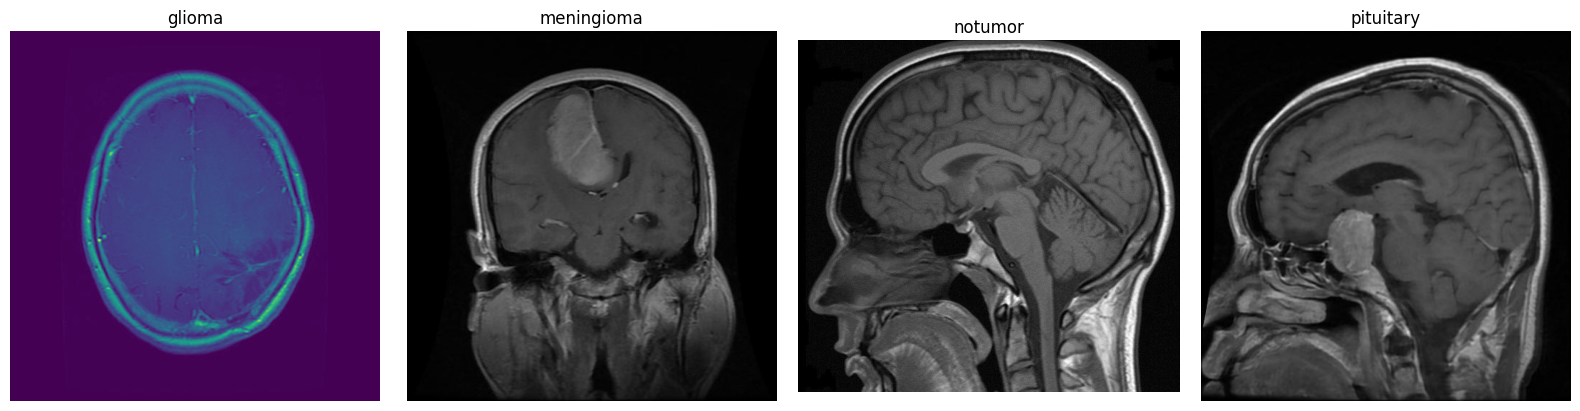

In [14]:
Plot_Classes(train_path)

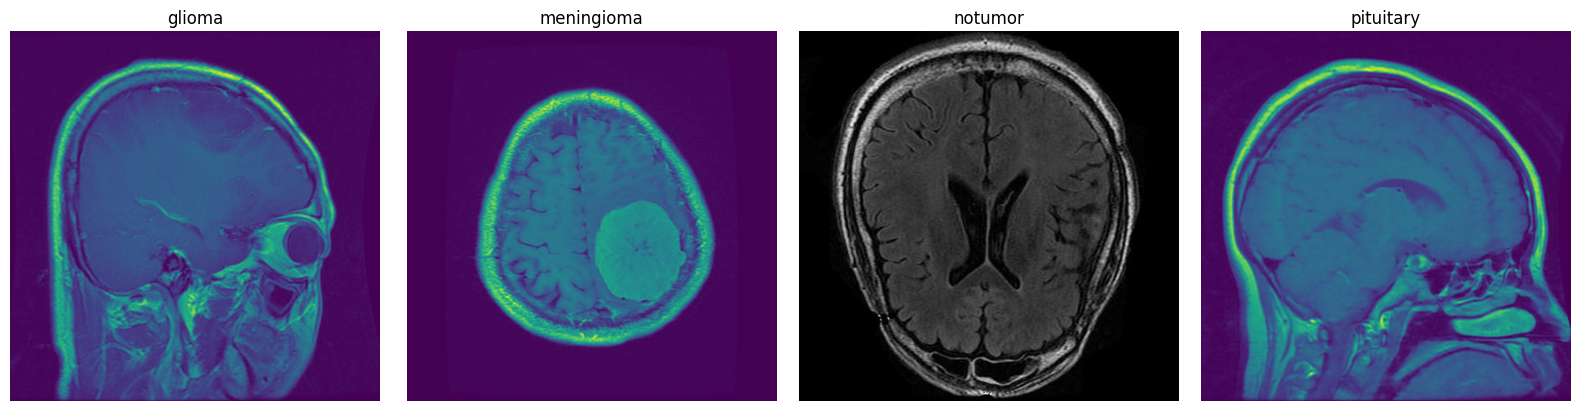

In [15]:
Plot_Classes(test_path)

In [16]:
train_data['Label'].value_counts()

,count
Label,
notumor,1400
glioma,1400
pituitary,1400
meningioma,1400


In [17]:
px.histogram(train_data, y="Label", color="Label", title="Classes Distribution")

In [18]:
test_data['Label'].value_counts()

,count
Label,
notumor,400
glioma,400
pituitary,400
meningioma,400


In [19]:
px.histogram(test_data, y="Label", color="Label", title="Classes Distribution")

In [20]:
# Define input image dimensions (width, height)
image_size = (150, 150)  # Can also use (224, 224) for pretrained models like VGG, ResNet

# Set the batch size for training
batch_size = 32  # Common values: 16, 32, 64 depending on memory/GPU

In [21]:
# ----------------------------
# Data Augmentation for Training
# ----------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15,         # 15% for validation from training set
    rotation_range=10,             # Random rotation in range [-10, 10]
    brightness_range=(0.85, 1.15), # Random brightness adjustment
    width_shift_range=0.002,       # Slight horizontal shift
    height_shift_range=0.002,      # Slight vertical shift
    shear_range=12.5,              # Shearing for distortion
    zoom_range=0.0,                # No zoom
    horizontal_flip=True,          # Flip horizontally
    vertical_flip=False,           # Don't flip vertically (not suitable for most medical/natural images)
    fill_mode="nearest"            # Fill in missing pixels
)

# ----------------------------
# Preprocessing for Validation (No Augmentation)
# ----------------------------
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15
)

# ----------------------------
# Training Data Generator
# ----------------------------
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    seed=0
)

# ----------------------------
# Validation Data Generator
# ----------------------------
val_generator = val_datagen.flow_from_directory(
    train_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    seed=0
)

# ----------------------------
# Test Data Generator (Only Rescale)
# ----------------------------
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False,
    seed=0
)

Found 4760 images belonging to 4 classes.
Found 840 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [22]:
def show_ImageDataGenerator(ImageDataGenerator, num_samples=5, figsize=(12, 12), save=False):
    """
    Function to viusalize how the ImageDataGenerator augments the data
    """

    # Generate augmented samples
    # Use __next__() instead of next()
    augmented_samples = train_generator.__next__()

    # Extract images from the batch
    images = augmented_samples[0][:num_samples]
    # Display the augmented images
    fig, axes = plt.subplots(1, num_samples, figsize=figsize)

    for i, ax in enumerate(axes):
        ax.imshow(images[i])
        ax.axis('off')

    plt.tight_layout()

    if save:
        plt.savefig('show_ImageDataGenerator.pdf')

    plt.show()

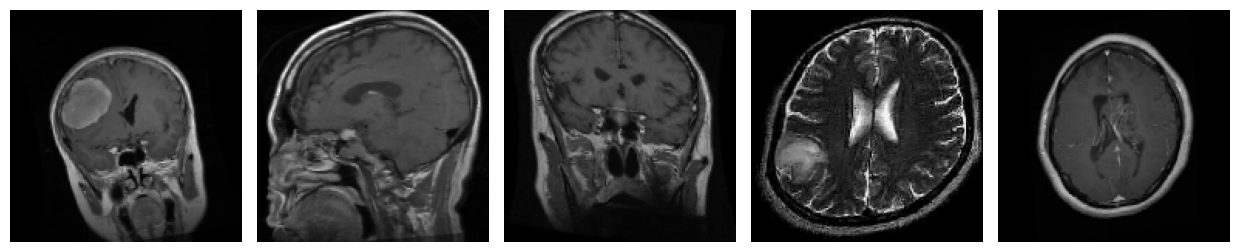

In [23]:
show_ImageDataGenerator(train_generator, num_samples=5, figsize=(12.5, 8), save=False)

In [24]:
# Define full image shape (height, width, channels)
image_shape = (image_size[0], image_size[1], 3)

# Summary
print("Dataset Summary")
print(f"Image shape              : {image_shape}")
print(f"Batch size               : {batch_size}")
print(f"Number of training batches   : {len(train_generator)}")
print(f"Number of validation batches : {len(val_generator)}")
print(f"Number of testing batches    : {len(test_generator)}")

Dataset Summary
Image shape              : (150, 150, 3)
Batch size               : 32
Number of training batches   : 149
Number of validation batches : 27
Number of testing batches    : 50


In [25]:
# Get class-to-index mapping from training generator
Classes_Map = train_generator.class_indices

# Total number of classes
num_classes = len(Classes_Map)

# Display results
print(f"Number of Classes: {num_classes}")
print("Class Index Mapping:")
for class_name, index in Classes_Map.items():
    print(f"  {index} → {class_name}")

Number of Classes: 4
Class Index Mapping:
  0 → glioma
  1 → meningioma
  2 → notumor
  3 → pituitary


In [26]:
def plot_curves(history):

    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]
    epochs = range(len(loss))

    plt.figure(figsize=(15, 5))
    plt.style.use('ggplot')

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'o-', color='#1f77b4', label="Train Loss")        # Blue
    plt.plot(epochs, val_loss, 'o-', color='#d62728', label="Val Loss")      # Red
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, 'o-', color='#2ca02c', label="Train Accuracy")  # Green
    plt.plot(epochs, val_accuracy, 'o-', color='#9467bd', label="Val Accuracy")# Purple
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.style.use('default')
    plt.show()

In [27]:
def CM(model, test_generator, categories):

    from sklearn.metrics import confusion_matrix
    # Predictions on test dataset
    predictions = model.predict(test_generator)
    predicted_categories = np.argmax(predictions, axis=1)
    true_categories = test_generator.classes

    # Create a confusion matrix
    confusion_matrix_array = confusion_matrix(true_categories, predicted_categories)
    print(f"Classification Report for {model}:")
    print(classification_report(true_categories, predicted_categories, target_names=categories))

    return confusion_matrix_array


def calculate_metrics(confusion_matrix, categories):

    # Calculating 4 different metrics
    precision = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=0)
    recall = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=1)
    f1_score = 2 * (precision * recall) / (precision + recall)
    accuracy = np.sum(np.diag(confusion_matrix)) / np.sum(confusion_matrix)

    # Printing the results based on each category
    for i, category in enumerate(categories):
        print(f"\n ***********************************")
        print(f"Class: {category.title()}")
        print(f"Precision: {precision[i]:.3f}")
        print(f"Recall: {recall[i]:.3f}")
        print(f"F1-Score: {f1_score[i]:.3f}\n")

    # Showing the total accuracy of the model
    print(f"\nAccuracy: {accuracy:.3f}")

In [28]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load the ResNet50 base model with pretrained ImageNet weights, exclude the top fully connected layers
base_model_resnet50 = ResNet50(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze all layers except last 10 layers
for layer in base_model_resnet50.layers[:-10]:
    layer.trainable = False

for layer in base_model_resnet50.layers[-10:]:
    layer.trainable = True

# Add custom classification head
x = base_model_resnet50.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax')(x)

# Final model assembly
model_resnet50 = Model(inputs=base_model_resnet50.input, outputs=output)

# Compile the model
model_resnet50.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print summary
model_resnet50.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 156, 156,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 75, 75,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 75, 75,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 75, 75,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 77, 77,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 38, 38,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 38, 38,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 38, 38,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 38, 38,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 38, 38,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 38, 38,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 38, 38,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 38, 38,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 38, 38,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 38, 38,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 38, 38,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 4,991,236 (19.04 MB)

 Non-trainable params: 19,122,048 (72.94 MB)

In [29]:
resnet50_history = model_resnet50.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator
)
model_resnet50.save('resnet50_brain_tumor_model.h5')

Epoch 1/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 87s 450ms/step - accuracy: 0.6647 - loss: 0.8105 - val_accuracy: 0.4167 - val_loss: 1.5327
Epoch 2/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 45s 300ms/step - accuracy: 0.7420 - loss: 0.6292 - val_accuracy: 0.4905 - val_loss: 1.4273
Epoch 3/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 45s 302ms/step - accuracy: 0.7546 - loss: 0.5827 - val_accuracy: 0.6619 - val_loss: 0.9680
Epoch 4/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 47s 316ms/step - accuracy: 0.7847 - loss: 0.5309 - val_accuracy: 0.7476 - val_loss: 0.6406
Epoch 5/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 39s 265ms/step - accuracy: 0.7987 - loss: 0.4958 - val_accuracy: 0.8024 - val_loss: 0.4864
Epoch 6/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 40s 267ms/step - accuracy: 0.7996 - loss: 0.4798 - val_accuracy: 0.7405 - val_loss: 0.6988
Epoch 7/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 40s 268ms/step - accuracy: 0.8120 - loss: 0.4679 - val_accuracy: 0.8036 - val_loss: 0.4799
Epoch 8/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 39s 265ms/step - accuracy: 0.8202 - loss: 0

In [32]:
!ls

 BRAIN_TUMOR_CLASSIFICATION.ipynb
 brain-tumor-mri-dataset
 Distribution_of_Training_Classes.ipynb
 FIGURE_PRECISION_RECALL_F1_SCORE.ipynb
 FINAL_VERSION_1_BRAIN_TUMOR_CLASSIFICATION.ipynb
 FINAL_VERSION_2_BRAIN_TUMOR_CLASSIFICATION.ipynb
'FINAL_VERSION_3_IMPROVED_EFFICIENT_BRAIN_TUMOR_CLASSIFICATION (1).ipynb'
 FINAL_VERSION_BRAIN_TUMOR_CLASSIFICATION.ipynb
 Memory_Size.ipynb
 Number_Of_Parameters.ipynb
 resnet50_brain_tumor_model.h5
 Test_Loss_And_Accuracy.ipynb


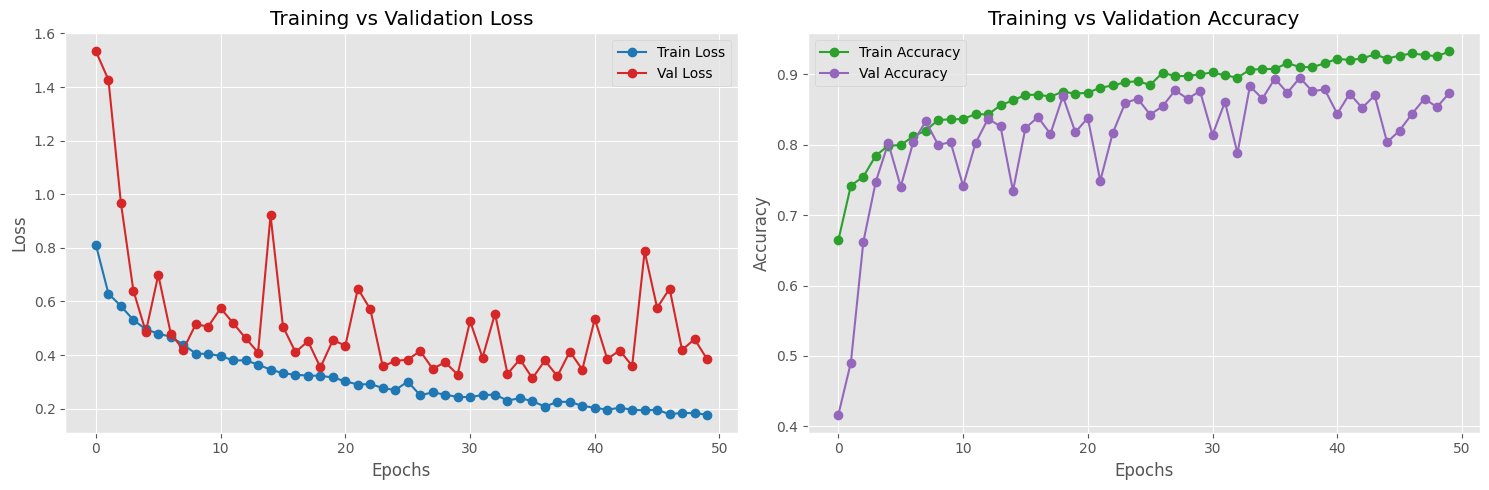

In [34]:
plot_curves(resnet50_history)

In [35]:
loss, accuracy = model_resnet50.evaluate(test_generator)
print(f" Test Loss     : {loss:.5f}")
print(f" Test Accuracy : {accuracy:.5f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.8788 - loss: 0.6924
 Test Loss     : 0.69241
 Test Accuracy : 0.87875


In [36]:
# Plotting confusion matrix
confusion_matrix = CM(model=model_resnet50, test_generator=test_generator, categories=classes)

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step
Classification Report for <Functional name=functional, built=True>:
              precision    recall  f1-score   support

     notumor       0.84      0.75      0.79       400
      glioma       0.83      0.81      0.82       400
   pituitary       0.89      0.99      0.93       400
  meningioma       0.95      0.97      0.96       400

    accuracy                           0.88      1600
   macro avg       0.88      0.88      0.88      1600
weighted avg       0.88      0.88      0.88      1600



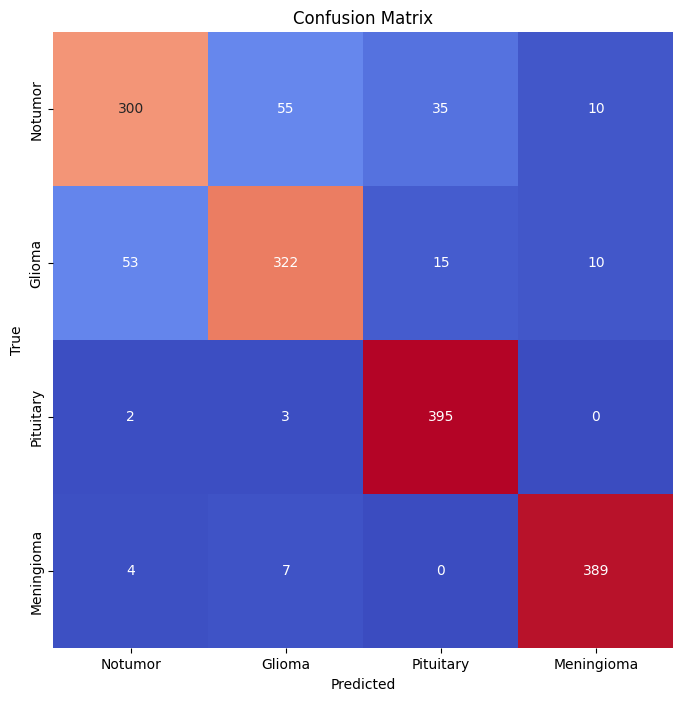

In [37]:
plt.figure(figsize=(8,8))
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="coolwarm", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(ticks=np.arange(4) + 0.5,
           labels=[name.title() for name in classes], ha='center')
plt.yticks(ticks=np.arange(4) + 0.5,
           labels=[name.title() for name in classes], va='center')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


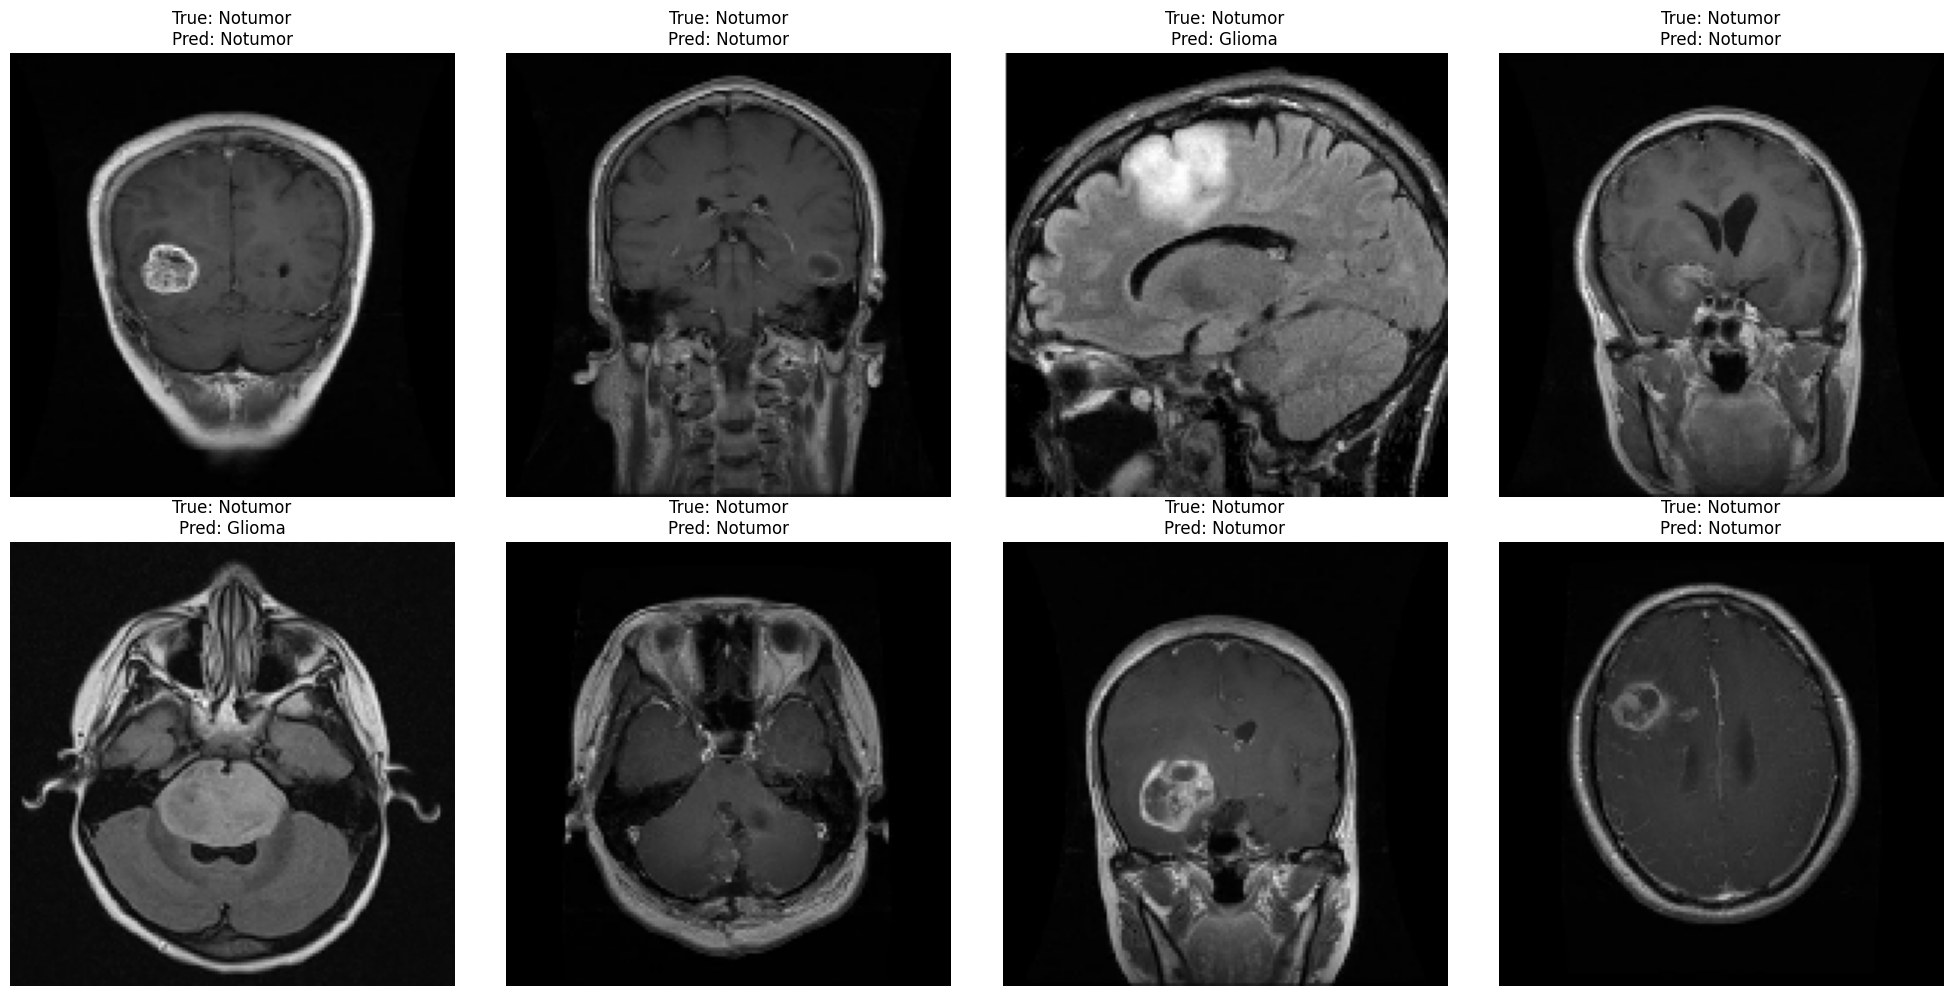

In [38]:
#model_mobilenetv1.save('mobilenetv1_brain_tumor_model.h5')

from tensorflow.keras.models import load_model
# Load the saved model
loaded_model = load_model('resnet50_brain_tumor_model.h5')

test_images, test_labels = next(test_generator)
predictions = loaded_model.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(test_labels, axis=1)
import matplotlib.pyplot as plt
import numpy as np

def plot_loaded_model_predictions(images, true_classes, predicted_classes, classes, num_samples=8):
    cols = 4
    rows = (num_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
    axes = axes.flatten()

    for i in range(num_samples):
        img = images[i]
        # If images are normalized to [0,1], no need to rescale
        axes[i].imshow(img)
        axes[i].set_title(f"True: {classes[true_classes[i]].title()}\nPred: {classes[predicted_classes[i]].title()}")
        axes[i].axis('off')

    # Hide any unused subplots
    for j in range(num_samples, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Call the plotting function
plot_loaded_model_predictions(test_images, true_classes, predicted_classes, classes, num_samples=8)